In [51]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
dataset


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [ ]:
dataset["train"][0]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:
import pandas as pd

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

In [ ]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [ ]:
test_df.head()

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0


In [ ]:
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (25000, 2)
Testing data shape: (25000, 2)


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


In [ ]:
train_df.isnull().sum()

,0
text,0
label,0


In [ ]:
train_df.duplicated().sum()

np.int64(96)

In [ ]:
train_df['label'].value_counts()

,count
label,
0,12500
1,12500


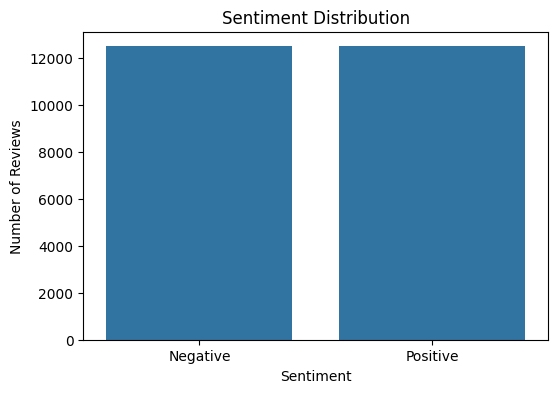

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x='label', data=train_df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks([0, 1], ['Negative', 'Positive'])

plt.show()

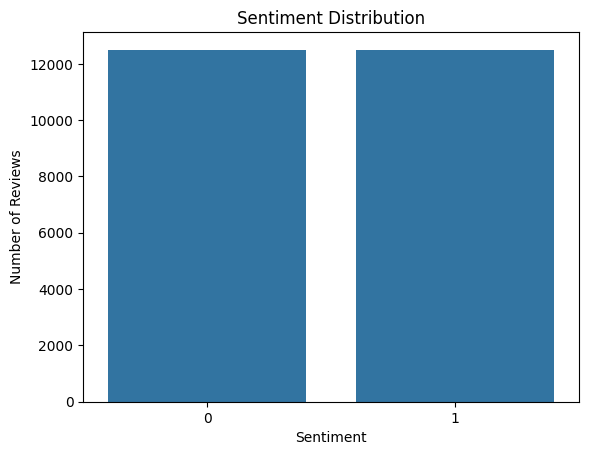

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label', data=train_df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
print("Negative Review:\n")
print(train_df[train_df['label'] == 0]['text'].iloc[0])

Negative Review:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few an

In [ ]:
print("\nPositive Review:\n")
print(train_df[train_df['label'] == 1]['text'].iloc[0])


Positive Review:

Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-crafted storyline. Zentropa is a bit disjointed in this respect. Perhaps this is intentional: it is presented as a dream/nightmare, and making it too coherent would spoil the effect. <br /><br />This movie is unrelentingly grim--"noir" in more than one sense; one never sees the sun shine. Grim, but intriguing, and frightening.


In [ ]:
train_df = train_df.dropna()
test_df = test_df.dropna()

In [ ]:
print(train_df.shape)
print(test_df.shape)

(25000, 2)
(25000, 2)


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
negation_words = {'no', 'not', 'nor', 'never'}

stop_words = stop_words - negation_words

In [ ]:
def preprocess_text(text):

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Tokenization
    tokens = word_tokenize(text)

    # Stop-word removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [ ]:
sample_review = train_df['text'].iloc[0]

print("ORIGINAL REVIEW:")
print(sample_review)

print("\n" + "="*80 + "\n")

print("PROCESSED REVIEW:")
print(preprocess_text(sample_review))

ORIGINAL REVIEW:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and

In [ ]:
train_df['cleaned_text'] = train_df['text'].apply(preprocess_text)

In [ ]:
test_df['cleaned_text'] = test_df['text'].apply(preprocess_text)

In [ ]:
train_df[['text', 'cleaned_text']].head()

,text,cleaned_text
0,I rented I AM CURIOUS-YELLOW from my video sto...,rented curiousyellow video store controversy s...
1,"""I Am Curious: Yellow"" is a risible and preten...",curious yellow risible pretentious steaming pi...
2,If only to avoid making this type of film in t...,avoid making type film future film interesting...
3,This film was probably inspired by Godard's Ma...,film probably inspired godard masculin féminin...
4,"Oh, brother...after hearing about this ridicul...",oh brotherafter hearing ridiculous film umptee...


In [ ]:
X_train = train_df['cleaned_text']
y_train = train_df['label']

X_test = test_df['cleaned_text']
y_test = test_df['label']

In [ ]:
X_train = train_df['cleaned_text']
y_train = train_df['label']

X_test = test_df['cleaned_text']
y_test = test_df['label']

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [ ]:
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
X_test_tfidf = tfidf.transform(X_test)

In [39]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (25000, 5000)
Testing TF-IDF shape: (25000, 5000)


In [40]:
model = LinearSVC(random_state=42)

model.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [41]:
y_pred = model.predict(X_test_tfidf)

In [42]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.87352
Accuracy (%): 87.35199999999999


In [43]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.87      0.88      0.87     12500
    Positive       0.88      0.87      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



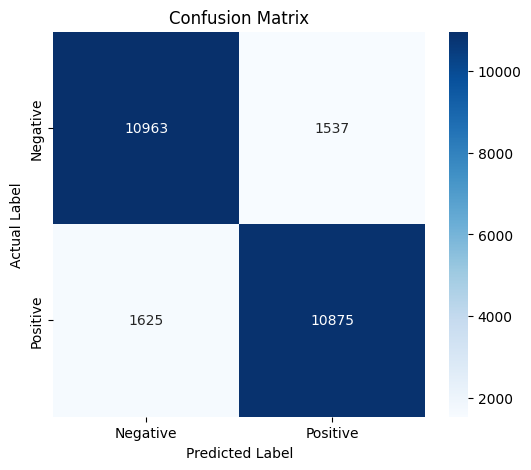

In [44]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [45]:
def predict_sentiment(review):

    cleaned_review = preprocess_text(review)

    review_tfidf = tfidf.transform([cleaned_review])

    prediction = model.predict(review_tfidf)[0]

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [46]:
review = "This movie was absolutely amazing. The acting was excellent and I loved every minute of it."

print("Review:", review)
print("Prediction:", predict_sentiment(review))

Review: This movie was absolutely amazing. The acting was excellent and I loved every minute of it.
Prediction: Positive


In [47]:
review = "This movie was terrible. The story was boring and the acting was disappointing."

print("Review:", review)
print("Prediction:", predict_sentiment(review))

Review: This movie was terrible. The story was boring and the acting was disappointing.
Prediction: Negative


In [48]:
new_reviews = [
    "I absolutely loved this movie. It was fantastic.",
    "This was one of the worst movies I have ever watched.",
    "The acting was excellent and the story was very interesting.",
    "The movie was boring and I regret watching it.",
    "A wonderful film with great performances."
]

for review in new_reviews:
    print("Review:", review)
    print("Prediction:", predict_sentiment(review))
    print("-" * 80)

Review: I absolutely loved this movie. It was fantastic.
Prediction: Positive
--------------------------------------------------------------------------------
Review: This was one of the worst movies I have ever watched.
Prediction: Negative
--------------------------------------------------------------------------------
Review: The acting was excellent and the story was very interesting.
Prediction: Positive
--------------------------------------------------------------------------------
Review: The movie was boring and I regret watching it.
Prediction: Negative
--------------------------------------------------------------------------------
Review: A wonderful film with great performances.
Prediction: Positive
--------------------------------------------------------------------------------


In [52]:
joblib.dump(model, "sentiment_svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [53]:
import os

print(os.listdir())

['.config', 'sentiment_svm_model.pkl', 'tfidf_vectorizer.pkl', 'sample_data']


In [54]:
from google.colab import files

files.download("sentiment_svm_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [55]:
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>